## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. load the data

In [2]:
df = pd.read_csv("Country-data.csv")
print(df.head())
print(df.shape)
print(df.info())

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  
(167, 10)
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null

check for missing values

In [3]:
print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [4]:
print(df.describe())

       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.810000    0.065900     609.000000   
25%      8.250000   23.800000    4.920000   30.200000    3355.000000   
50%     19.300000   35.000000    6.320000   43.300000    9960.000000   
75%     62.100000   51.350000    8.600000   58.750000   22800.000000   
max    208.000000  200.000000   17.900000  174.000000  125000.000000   

        inflation  life_expec   total_fer           gdpp  
count  167.000000  167.000000  167.000000     167.000000  
mean     7.781832   70.555689    2.947964   12964.155689  
std     10.570704    8.893172    1.513848   18328.704809  
min     -4.210000   32.100000    1.150000     231.000000  
25%      1.810000   65.300000    1.795000    1330.000000

## 3. EDA


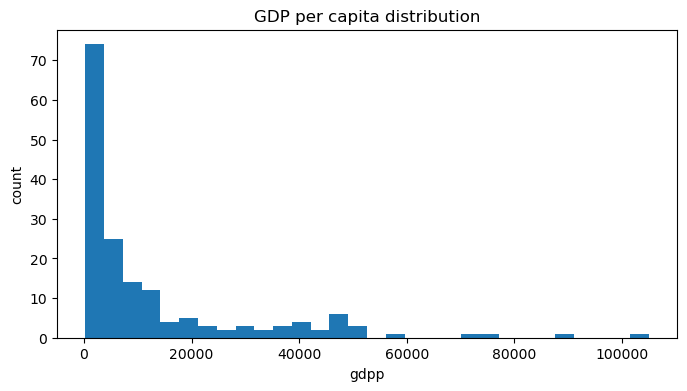

In [5]:
plt.figure(figsize=(8,4))
plt.hist(df['gdpp'], bins=30)
plt.title("GDP per capita distribution")
plt.xlabel("gdpp")
plt.ylabel("count")
plt.show()

boxplot for each numeric column to see outliers

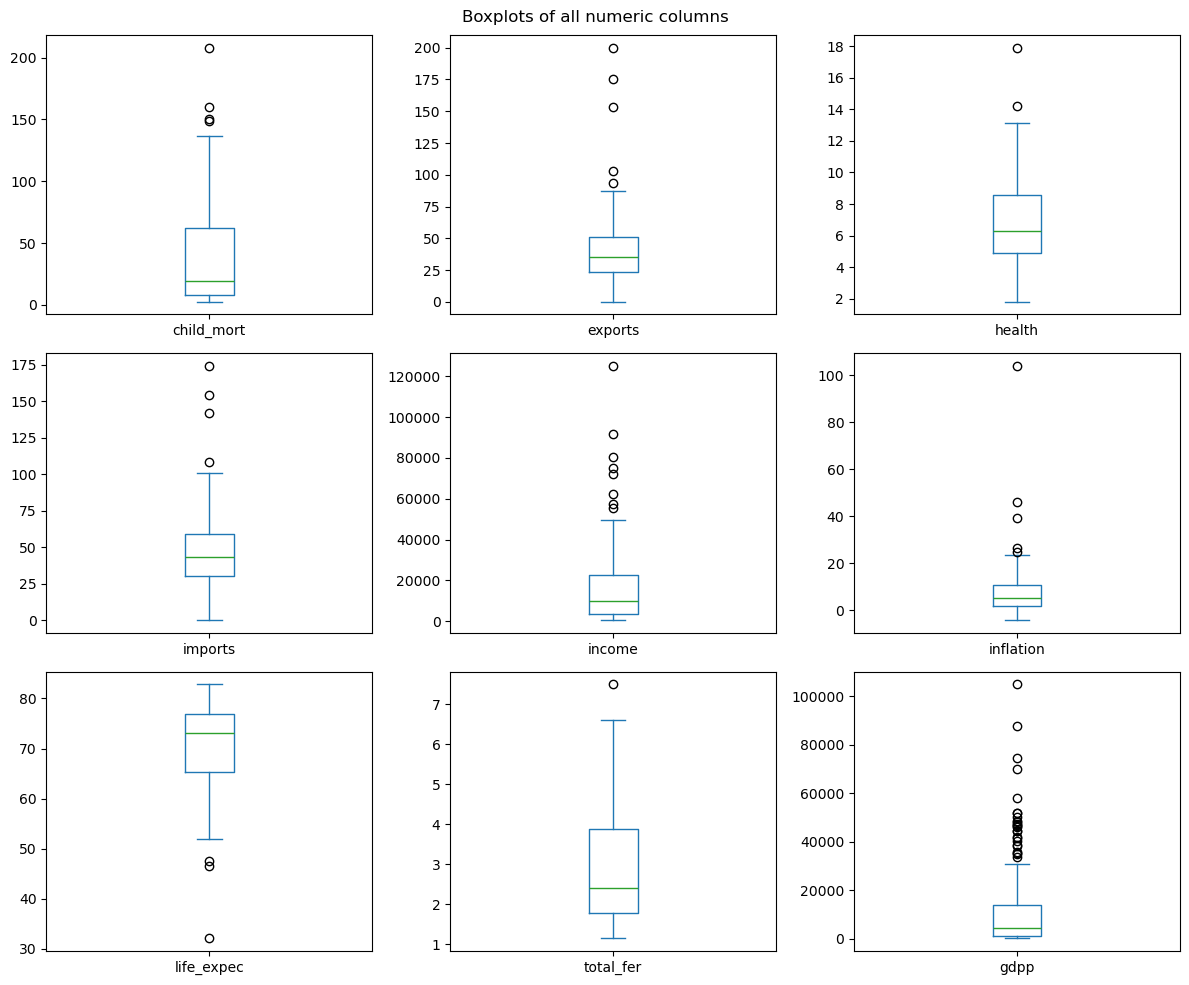

In [6]:
numeric_cols = ['child_mort', 'exports', 'health', 'imports',
                'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

df[numeric_cols].plot(kind='box', subplots=True, layout=(3,3), figsize=(12,10))
plt.suptitle("Boxplots of all numeric columns")
plt.tight_layout()
plt.show()

correlation heatmap (which columns are related to each other)

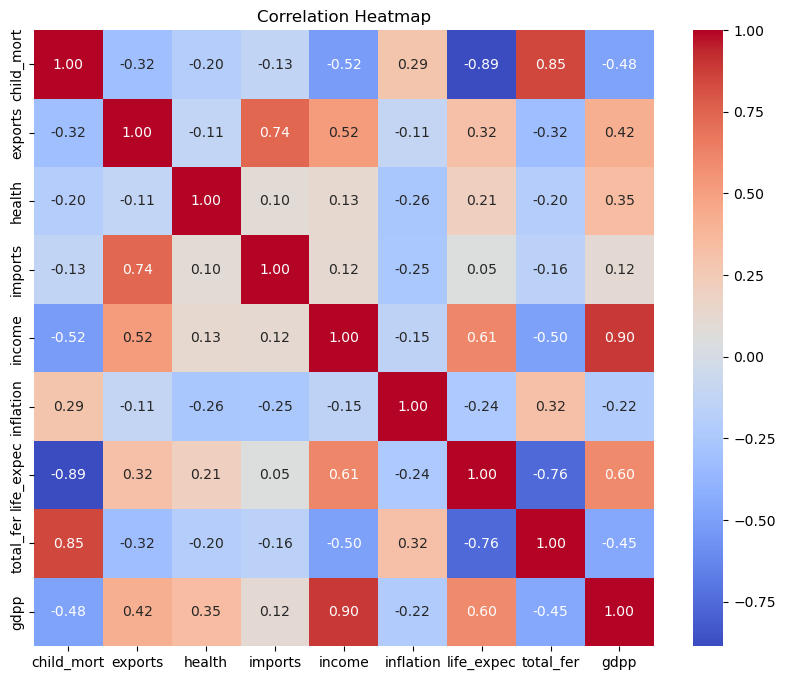

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

 what to notice from heatmap:    
- child_mort and life_expec are strongly negatively correlated (makes sense)
- income and gdpp are strongly positively correlated
- child_mort and total_fer also strongly related

## 4. Preprocessing

need to scale the data because columns have very different ranges    
example: gdpp goes upto 105000 but total_fer is only 1 to 7    
if we dont scale, gdpp will dominate

also remove country column because its text, not a number


In [8]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['child_mort', 'exports', 'health', 'imports',
                'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

features = df[numeric_cols]   # only numeric columns

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

# put it back as dataframe so column names are preserved
scaled_df = pd.DataFrame(scaled_data, columns=numeric_cols)
print(scaled_df.head())

   child_mort   exports    health   imports    income  inflation  life_expec  \
0    1.291532 -1.138280  0.279088 -0.082455 -0.808245   0.157336   -1.619092   
1   -0.538949 -0.479658 -0.097016  0.070837 -0.375369  -0.312347    0.647866   
2   -0.272833 -0.099122 -0.966073 -0.641762 -0.220844   0.789274    0.670423   
3    2.007808  0.775381 -1.448071 -0.165315 -0.585043   1.387054   -1.179234   
4   -0.695634  0.160668 -0.286894  0.497568  0.101732  -0.601749    0.704258   

   total_fer      gdpp  
0   1.902882 -0.679180  
1  -0.859973 -0.485623  
2  -0.038404 -0.465376  
3   2.128151 -0.516268  
4  -0.541946 -0.041817  


## 5. make a label for classification

the original dataset has no labels (thats why its called unsupervised)
so, i will create a label using gdpp to say developed or not

In [9]:
# median split - above median = 1 (developed), below = 0 (not developed)
median_gdp = df['gdpp'].median()
print("median gdpp:", median_gdp)

df['label'] = (df['gdpp'] > median_gdp).astype(int)

print(df['label'].value_counts())
# 0 = below median gdp (not developed)
# 1 = above median gdp (developed)

median gdpp: 4660.0
label
0    84
1    83
Name: count, dtype: int64


## 6.train test split

always split data before training. never train on test data.   
note: our dataset is small (167 rows) so test set will only be ~33 rows

In [10]:
from sklearn.model_selection import train_test_split

X = scaled_df          # 9 numeric features, scaled
y = df['label']        # 0 or 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("train size:", X_train.shape)   
print("test size:", X_test.shape)     

train size: (133, 9)
test size: (34, 9)


## 7.Classification (Logistic Regression)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.8823529411764706
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        15
           1       1.00      0.79      0.88        19

    accuracy                           0.88        34
   macro avg       0.89      0.89      0.88        34
weighted avg       0.91      0.88      0.88        34



## 8. Random Forest (ensemble method)

random forest = many decision trees put together. usually gives better results than one tree.

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       1.00      0.89      0.94        19

    accuracy                           0.94        34
   macro avg       0.94      0.95      0.94        34
weighted avg       0.95      0.94      0.94        34



feature importance - which column helps the model the most

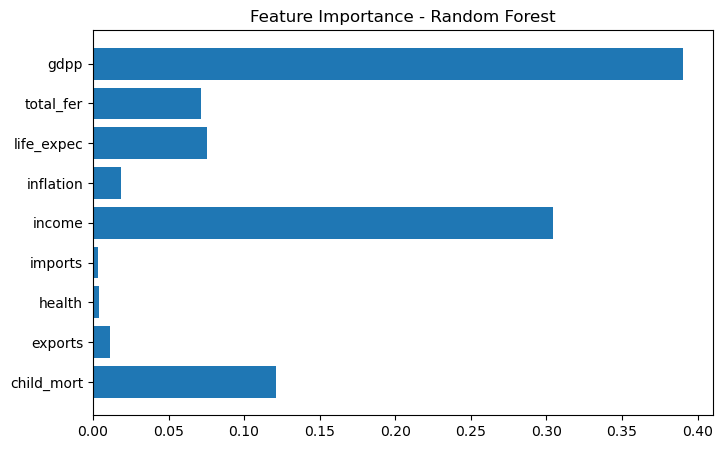

In [13]:
importances = rf.feature_importances_
feat_names = numeric_cols   

plt.figure(figsize=(8,5))
plt.barh(feat_names, importances)
plt.title("Feature Importance - Random Forest")
plt.show()
# gdpp and income should be most important since we created label from gdpp

## 9. XGBoost (ensemble method)

xgboost is more advanced than random forest. it trains trees one after another and fixes mistakes

In [14]:
from xgboost import XGBClassifier

# note: removed use_label_encoder parameter, it causes warning in new xgboost versions
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.95      0.97        19

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



## 10. Compare all classifiers

In [15]:
results = {
    'Logistic Regression': accuracy_score(y_test, y_pred),
    'Random Forest':       accuracy_score(y_test, y_pred_rf),
    'XGBoost':             accuracy_score(y_test, y_pred_xgb)
}

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.8824
Random Forest: 0.9412
XGBoost: 0.9706


## 11. K-Means Clustering

now back to unsupervised. clustering means grouping countries that are similar.
k-means needs no of groups we want

first find the best k using elbow method

C:\Users\mishr\anaconda3\envs\country\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\mishr\anaconda3\envs\country\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mishr\anaconda3\envs\country\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with M

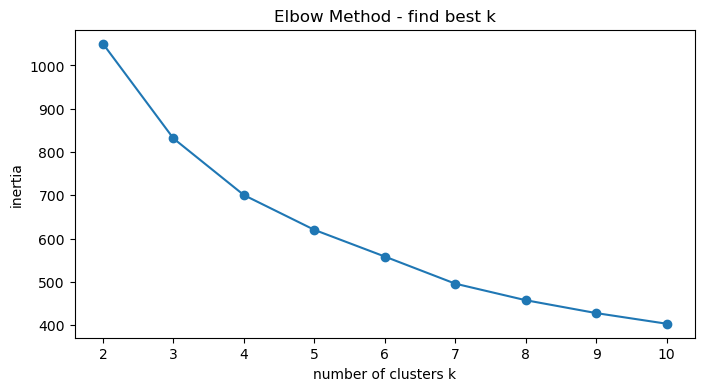

In [16]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 11)

for k in k_range:
    # n_init=10 added to avoid warning in newer sklearn versions
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method - find best k")
plt.xlabel("number of clusters k")
plt.ylabel("inertia")
plt.show()

pick k where the curve bends (elbow). for this dataset k=3 is usually the answer.   
cluster 0 = underdeveloped, cluster 1 = developing, cluster 2 = developed

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(scaled_data)

print(df['kmeans_cluster'].value_counts())

kmeans_cluster
2    84
1    47
0    36
Name: count, dtype: int64


C:\Users\mishr\anaconda3\envs\country\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


visualize clusters using pca (reduce to 2 dimensions for plotting)

variance explained by PC1 and PC2: 0.631333654377141


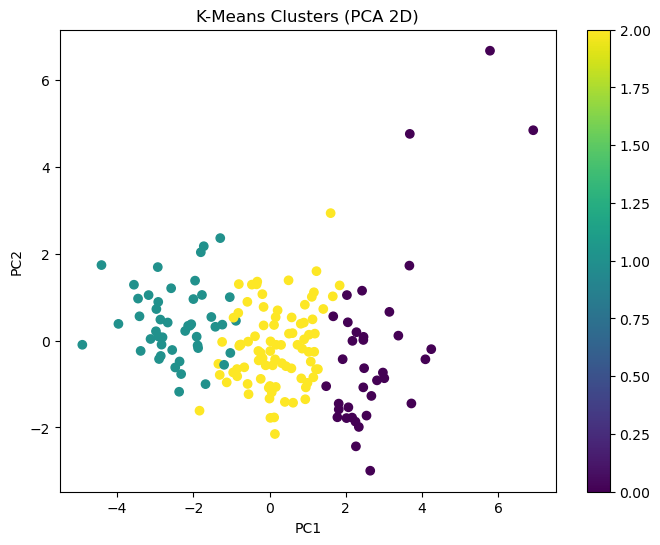

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print("variance explained by PC1 and PC2:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8,6))
scatter = plt.scatter(pca_data[:,0], pca_data[:,1], c=df['kmeans_cluster'], cmap='viridis')
plt.colorbar(scatter)
plt.title("K-Means Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## 12. DBSCAN Clustering

dbscan is different from k-means. it finds clusters based on density, 
we dont need to tell it how many clusters. it figures it out itself
but we need to tune eps and min_samples

In [19]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(scaled_data)

print(df['dbscan_cluster'].value_counts())
# -1 means noise / outlier points that dont belong to any cluster

dbscan_cluster
 0    137
-1     30
Name: count, dtype: int64


visualize dbscan

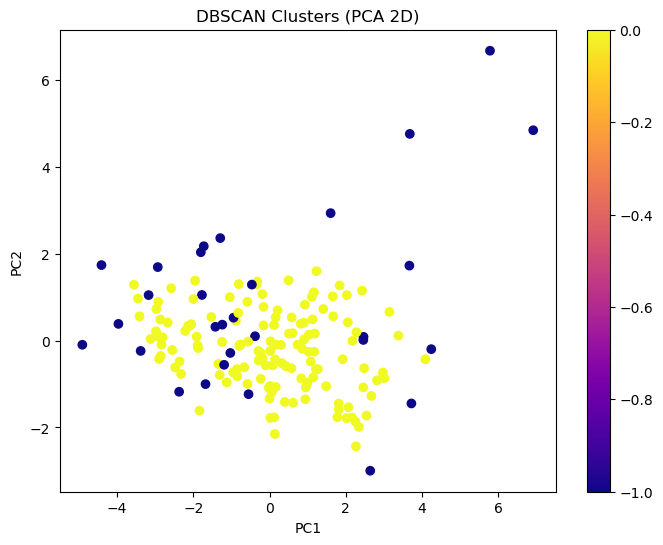

In [20]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(pca_data[:,0], pca_data[:,1], c=df['dbscan_cluster'], cmap='plasma')
plt.colorbar(scatter)
plt.title("DBSCAN Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

after clustering always check what kind of countries ended up in each group

In [21]:
# defining numeric_cols again here just to be safe
numeric_cols = ['child_mort', 'exports', 'health', 'imports',
                'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

cluster_summary = df.groupby('kmeans_cluster')[numeric_cols].mean()
print(cluster_summary)

                child_mort    exports    health    imports        income  \
kmeans_cluster                                                             
0                 5.000000  58.738889  8.807778  51.491667  45672.222222   
1                92.961702  29.151277  6.388511  42.323404   3942.404255   
2                21.927381  40.243917  6.200952  47.473404  12305.595238   

                inflation  life_expec  total_fer          gdpp  
kmeans_cluster                                                  
0                2.671250   80.127778   1.752778  42494.444444  
1               12.019681   59.187234   5.008085   1922.382979  
2                7.600905   72.814286   2.307500   6486.452381  


which countries are in which cluster

In [22]:
for c in sorted(df['kmeans_cluster'].unique()):
    countries = df[df['kmeans_cluster'] == c]['country'].tolist()
    print(f"\nCluster {c} ({len(countries)} countries):")
    print(countries)


Cluster 0 (36 countries):
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']

Cluster 1 (47 countries):
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan'

## 13. Hyperparameter tuning for Random Forest

tuning means finding the best settings for the model    
note: dataset is small (167 rows) so cv=5 is fine here

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)

print("best params:", grid_search.best_params_)
print("best cv score:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print("test accuracy after tuning:", accuracy_score(y_test, y_pred_best))

best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
best cv score: 0.9925925925925926
test accuracy after tuning: 0.9411764705882353


## 14. confusion matrix

confusion matrix shows where the model made mistakes

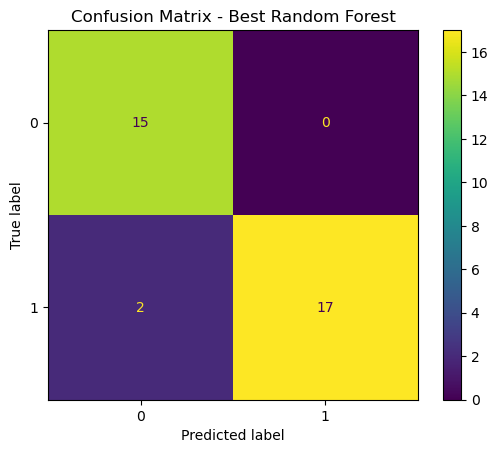

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)
plt.title("Confusion Matrix - Best Random Forest")
plt.show()

# rows = actual labels
# columns = predicted labels
# diagonal = correct predictions

## theory notes

**classification** = predicting a category (like developed vs not developed)

**ensemble learning** = combining many weak models to make one strong model
- random forest = parallel trees, each trained on random subset
- xgboost = sequential trees, each one fixes errors of previous

**clustering** = grouping similar data points together without labels
- kmeans = partition based, need to set k, use elbow method to find k
- dbscan = density based, handles noise, -1 label means outlier

**scaling** = important so that one big column doesnt dominate others
- example: gdpp (max ~105000) vs total_fer (max ~7.5)

**pca** = principal component analysis, reduces dimensions while keeping most info
- useful for visualization (plot 9 columns in 2d)

**confusion matrix** = table showing correct vs wrong predictions
- top left = true negatives, bottom right = true positives
- off diagonal = mistakes
